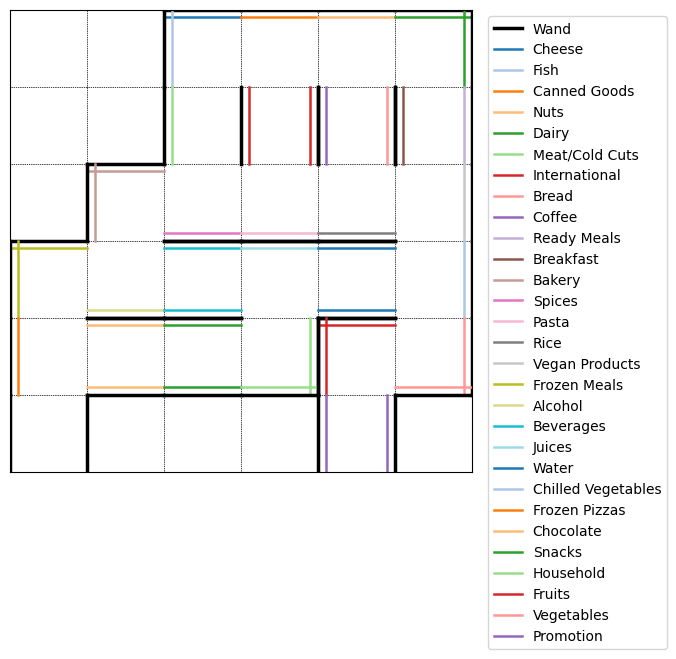

In [1]:
from supermarket import Grid
grid = Grid("supermarket-grids/grid_eng.txt")
grid.plot(saving_path="empty_grid.jpg")

## Computing Cost-/Path-Matrix for the different product-types

In [2]:
from distance import compute_optimal_trajectories
J_product_category, P_product_category, product_type_indizes = compute_optimal_trajectories(grid, (5,4), (5,0))

## Computing Cost-/Path-Matrix for the different products based on the matrizes of the product_types

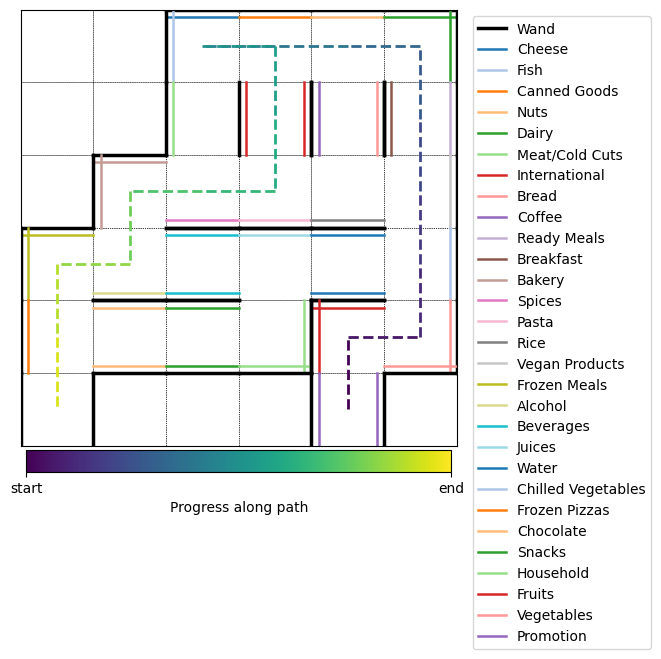

In [3]:
from shopping_list import ShoppingList
from distance import create_product_cost_path_matrix

shopping_list = ShoppingList.load_from_file("shopping-lists/small_shopping_list.txt")

J_product, P_product = create_product_cost_path_matrix(shopping_list, J_product_category, P_product_category, product_type_indizes)

grid.plot([P_product[0, 1], P_product[1, 3], P_product[3, 7]], saving_path="grid_with_path.jpg")


## Easy heuristic for optimal route by length  
Unfortunaltely this computation scales by n!, where n is the number of items on the shopping list. Therefore this might not be the preferred algorithm for big shopping_lists.

In [4]:
from itertools import permutations
import numpy as np
import distance

def find_shortest_way_easy_heuristic(product_cost_matrix):
    n = product_cost_matrix.shape[0]

    middle_indices = list(range(1, n-1))
    best_cost = np.inf
    best_order = None

    for order in permutations(middle_indices):
        cost = distance.compute_timecost_from_middle_indices_order(order, product_cost_matrix)
        if cost < best_cost:
            best_cost = cost
            best_order = order

    return best_order, best_cost

(6, 2, 1, 3, 5, 4) 18


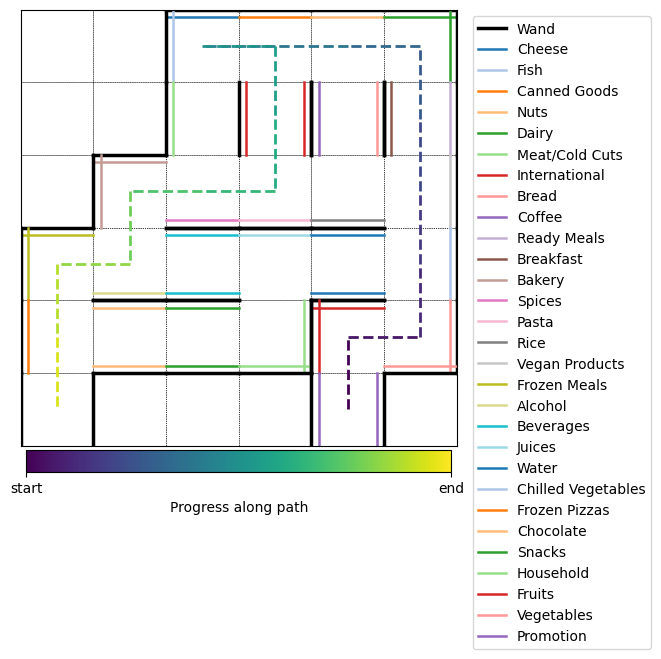

In [5]:
import distance
import order_functions

shortest_order, shortest_order_cost = find_shortest_way_easy_heuristic(J_product)
shortest_path = order_functions.get_path_from_middle_indices_order(shortest_order, P_product)
print(shortest_order, shortest_order_cost)
grid.plot(shortest_path, saving_path="Time brute-force-heuristic.jpg")

# Load shopping list

In [7]:
from shopping_list import ShoppingList

shopping_list = ShoppingList.load_from_file("shopping-lists/long_shopping_list.txt")


# Single solution based mataheuristic

In [8]:
import math
from distance import create_product_cost_path_matrix

J_product, P_product = create_product_cost_path_matrix(shopping_list, J_product_category, P_product_category, product_type_indizes)
print(f"Theoretical number of orders possible: {math.factorial(len(shopping_list))}")

Theoretical number of orders possible: 10888869450418352160768000000


## Local search

In [9]:
import distance
import plotting


def perform_local_search_m_times(m, J_product, compute_neighbours_func, shopping_list, saving_path = None):
    best_orders, best_order_costs = [], []
    for i in range(m):
        best_order, best_order_cost = distance.local_search(J_product, compute_neighbours_func=compute_neighbours_func)
        best_orders.append(best_order)
        best_order_costs.append(best_order_cost)
    plotting.plot_costs(best_order_costs, shopping_list=shopping_list, saving_path=saving_path)


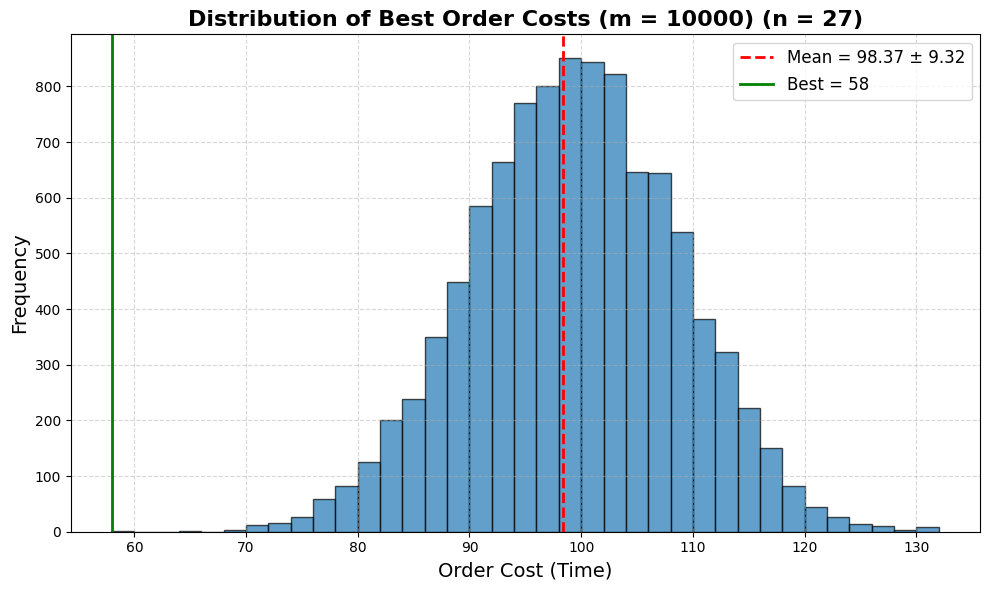

In [10]:
import order_functions
perform_local_search_m_times(10000, J_product, order_functions.compute_neighbours1, shopping_list, saving_path = "local_search_consecutive_neighbours.jpg")

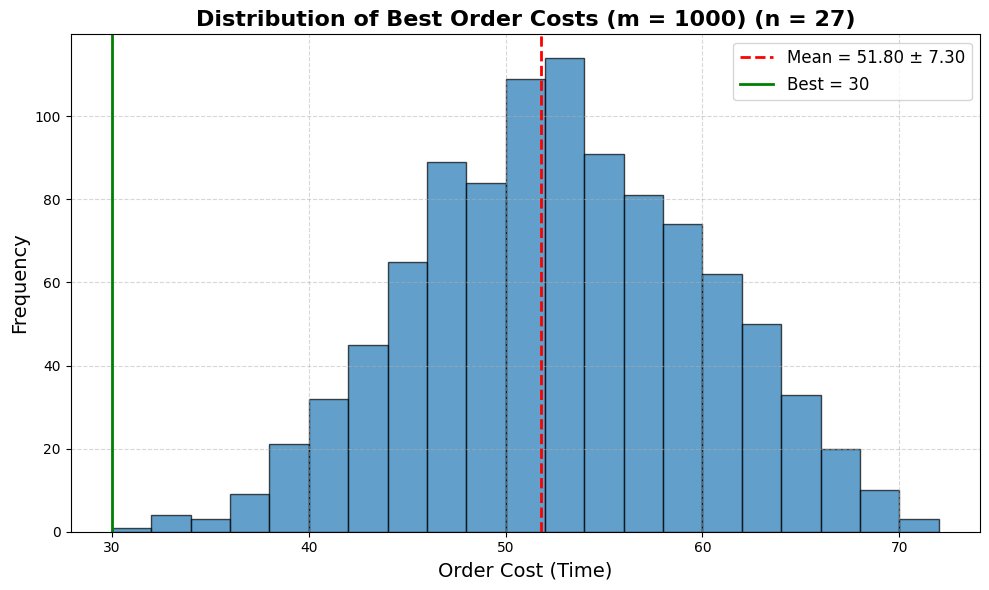

In [11]:
perform_local_search_m_times(1000, J_product, order_functions.compute_neighbours2, shopping_list, saving_path="local_search_random_neighbours.jpg")

# GRASP

In [12]:


def perform_GRASP_m_times(m, J_product, compute_neighbours_func, shopping_list, alpha = 0.5, saving_path = None):
    best_orders, best_order_costs = [], []
    for i in range(m):
        best_order, best_order_cost = distance.GRASP(J_product, compute_neighbours_func, alpha = alpha)
        best_orders.append(best_order)
        best_order_costs.append(best_order_cost)

    plotting.plot_costs(best_order_costs, shopping_list=shopping_list, saving_path=saving_path)
    index = best_order_costs.index(min(best_order_costs))
    best_order = best_orders[index]
    return best_order

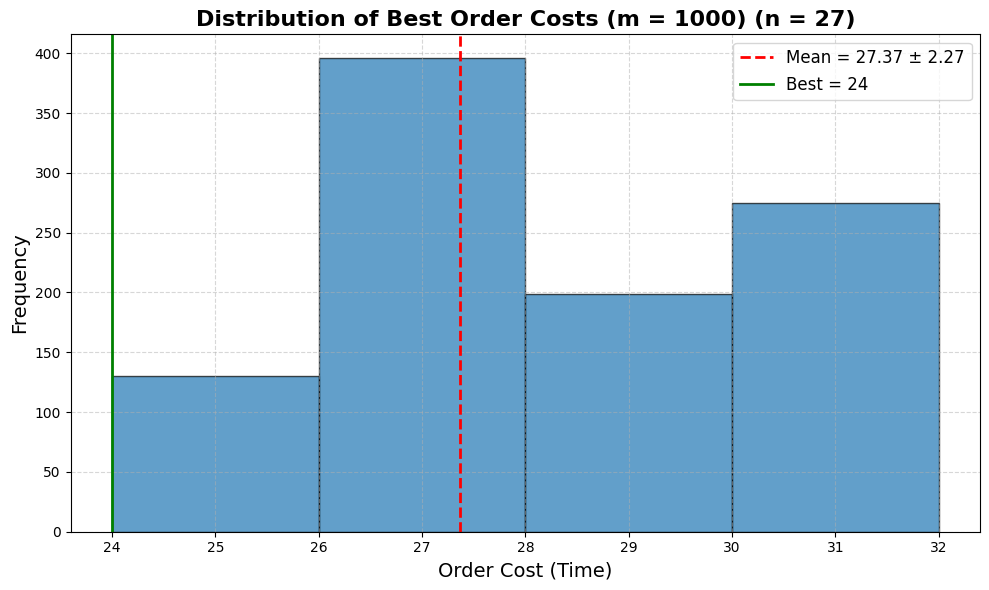

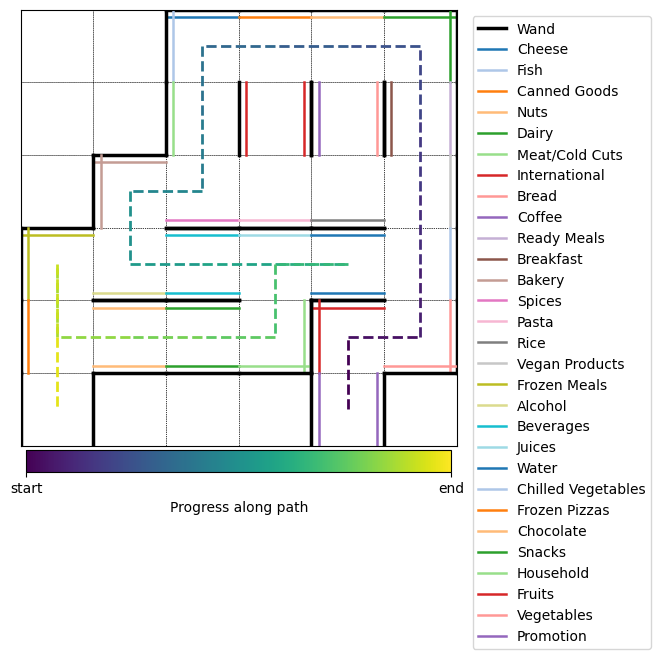

In [13]:
best_order = perform_GRASP_m_times(1000, J_product, order_functions.compute_neighbours1, shopping_list, alpha = 0.1, saving_path="histogramm_grasp.jpg")
best_path = order_functions.get_path_from_middle_indices_order(best_order, P_product)
grid.plot(best_path, saving_path="GRASP_path.jpg")

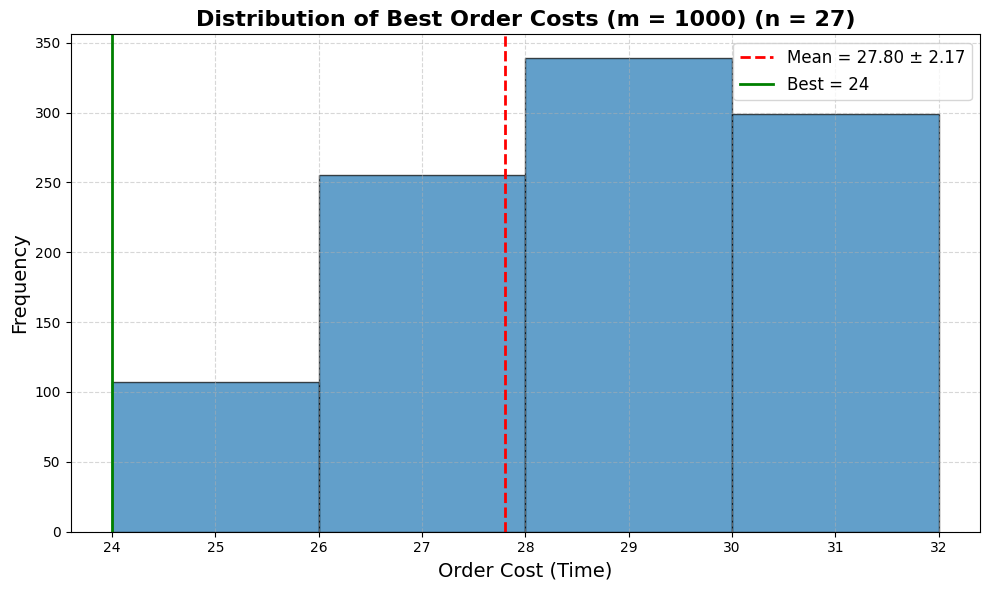

In [14]:
_ = perform_GRASP_m_times(1000, J_product, order_functions.compute_neighbours2, shopping_list, alpha = 0.1)

# Population based metaheuristics

## Evolutionary algorithm

44


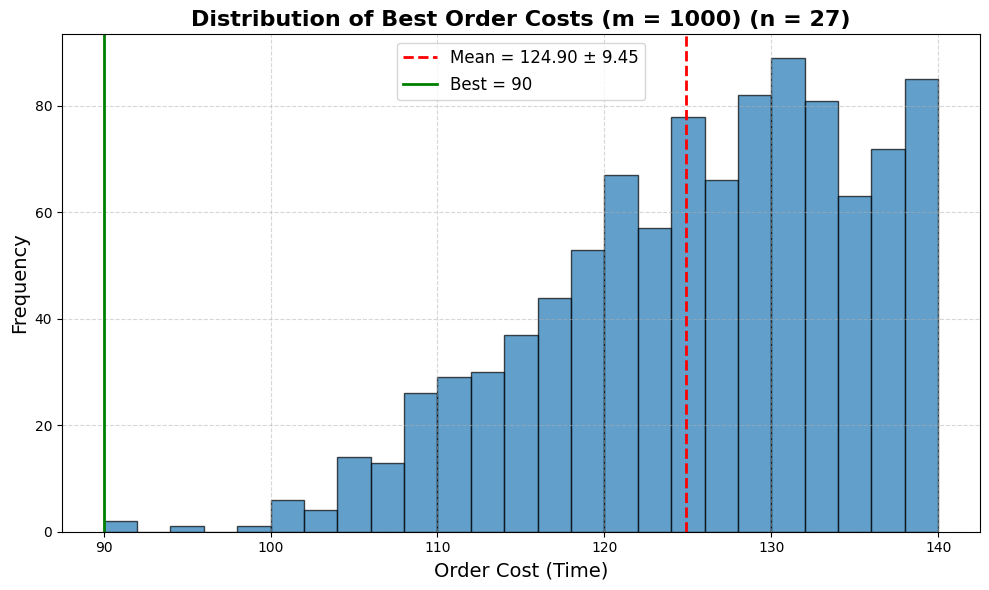

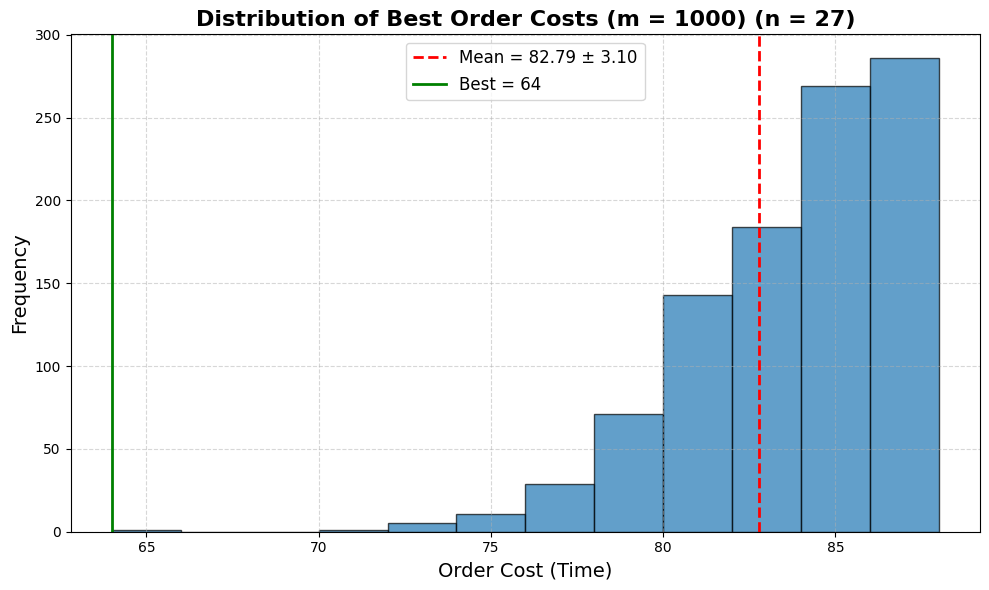

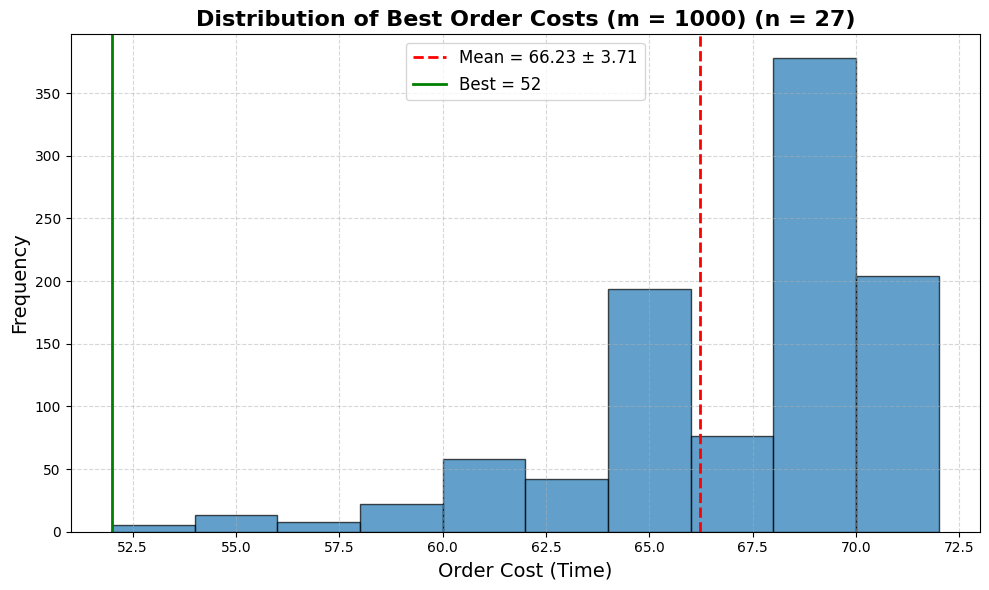

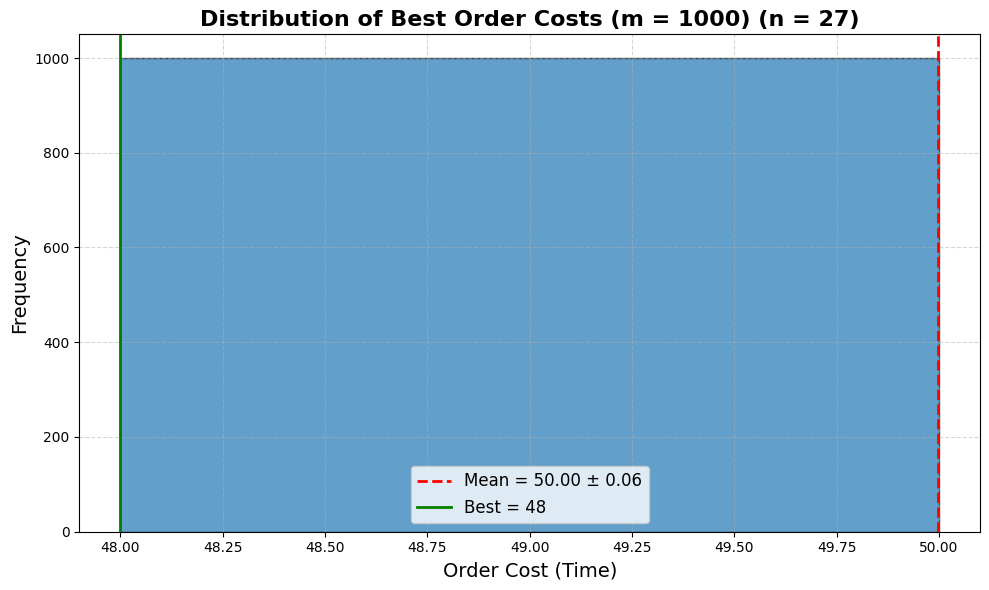

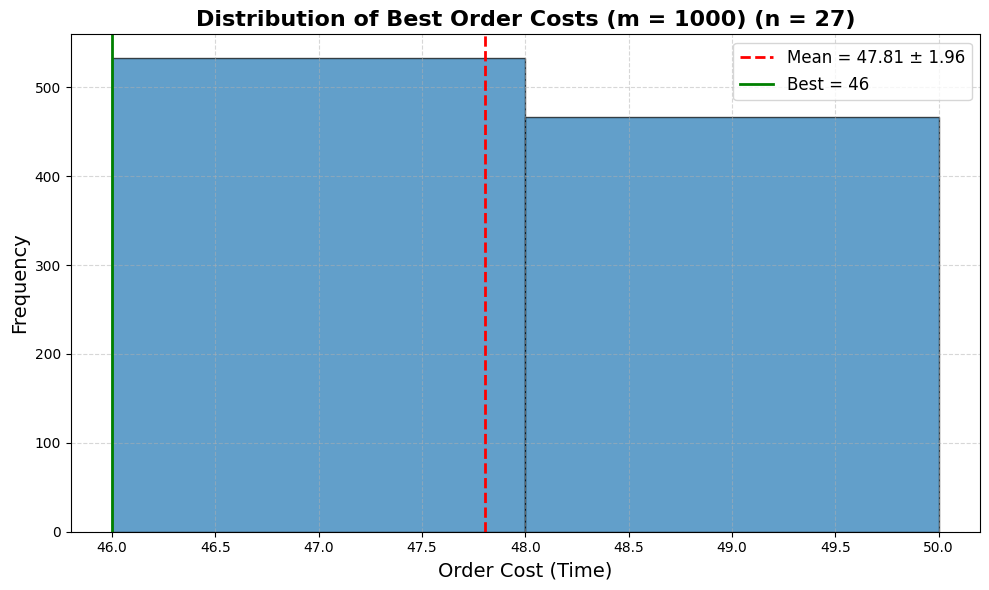

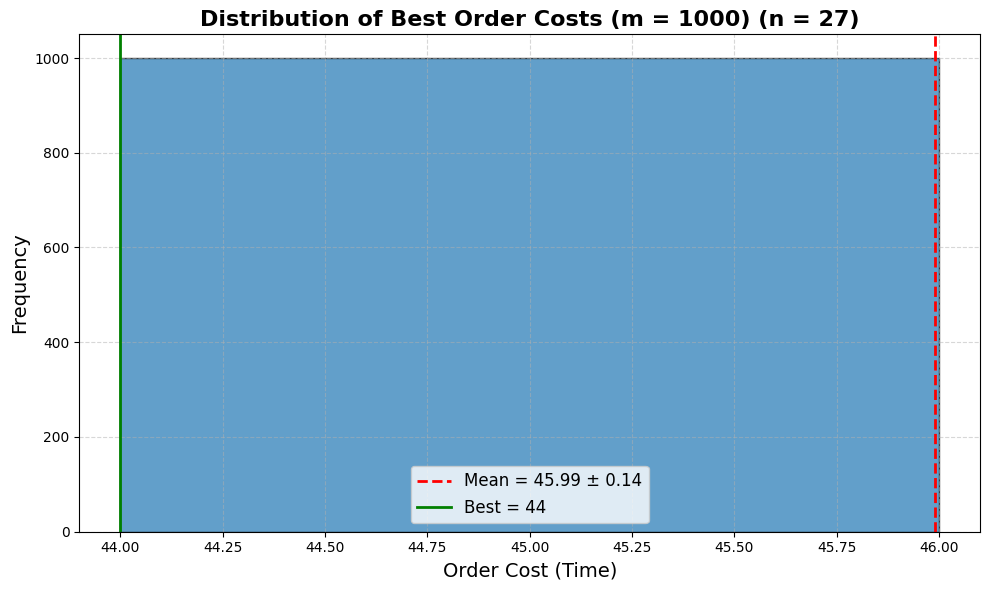

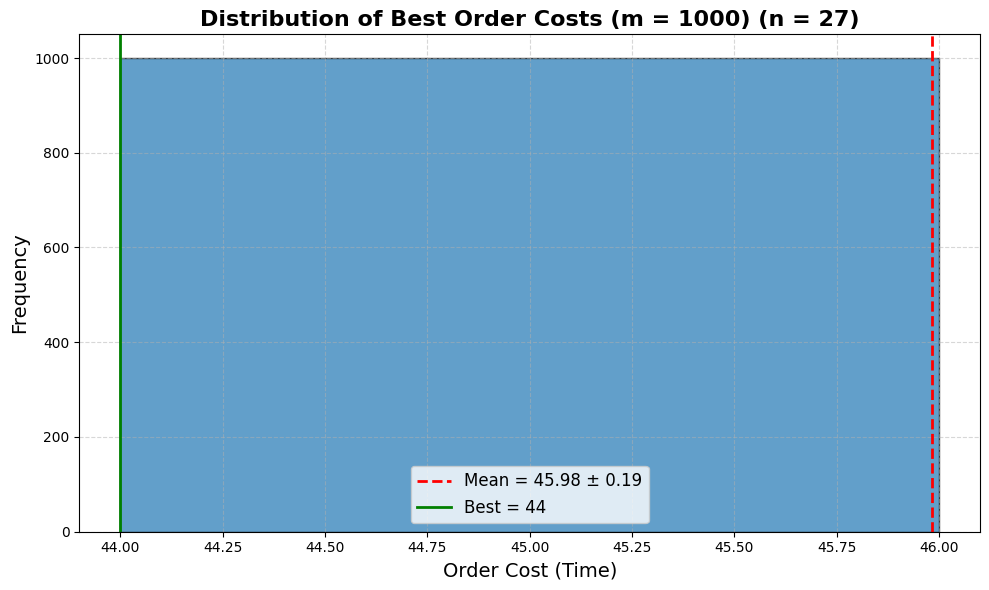

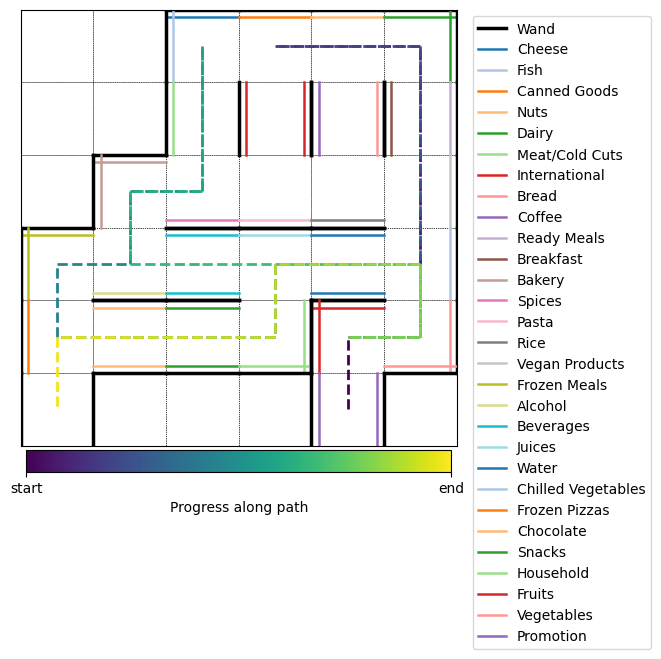

In [16]:
import random
import plotting as pl
def generate_random_initial_population(population_size, number_of_products):
    # population_size: d
    # O(d)
    population = []
    for i in range(population_size):
        order = order_functions.generate_random_order(number_of_products)
        #order = get_complete_order(order, 0, number_of_products + 1)
        population.append(order)
    return population

def evaluate_population(population, J_product):
    # O(d * n)
    population_costs = []
    for order in population:
        order_cost = distance.compute_timecost_from_middle_indices_order(order, J_product)
        population_costs.append(order_cost)
    return population_costs

def sort_population_by_fitness(population, population_costs):
    # population_size: d
    # O(d*log(d))
    population_costs, population = zip(*sorted(zip(population_costs, population)))
    return list(population), list(population_costs)

def tournament_selection(population:list, population_costs:list, generation_size:int, k:int = 4):
    # g = generation size
    # O(g)
    selected_population = []
    #selected_population_costs = []
    for i in range(generation_size):
        tournament_group = random.choices(population, k=k)
        tournament_group_costs = [population_costs[population.index(fighter)] for fighter in tournament_group]

        best_fighter_cost = min(tournament_group_costs)
        best_fighter_index = tournament_group_costs.index(best_fighter_cost)
        best_fighter = tournament_group[best_fighter_index]

        selected_population.append(best_fighter)
        #selected_population_costs.append(best_fighter_cost)
    return selected_population

def crossover_reproduction(selected_population:list):
    # s = len(selected population) = g/2
    # O(g * n)
    number_of_products = len(selected_population[0])
    crossover_line = int(number_of_products/2)
    children = []
    for i in range(0,len(selected_population),2):
        male, female = selected_population[i], selected_population[i+1]
        child = male[:crossover_line]
        while len(child) < len(male):
            child.append(next(product for product in female if (product not in child)))
        children.append(child)
    return children



def mutate_population(population:list, population_costs:list, J_product, p:float = 0.3):
    # population_size: d
    # O(d * n)
    for i in range(len(population)):
        if random.random() < p:
            population[i] = order_functions.mutation(population[i])
            population_costs[i] = distance.compute_timecost_from_middle_indices_order(population[i], J_product)
    return population, population_costs

def evolution(J_product, population_size = 100, generation_size = 10, patience = 10, plotting = False, printing = False):
    # r = total generations/rounds
    # d = population_size
    # n = number of products on shopping list
    # g = generation sizes
    # r*(O(g) + O(g*n) + O(d*n) + O(d*n) +O(d*log(d))
    # g < d -> O(g) < O(g*n) < O(d*n)
    # O(r * d * (n + log(d)))
    number_of_products = J_product.shape[0]-2
    population = generate_random_initial_population(population_size, number_of_products)
    population_costs = evaluate_population(population, J_product)
    population, population_costs = sort_population_by_fitness(population, population_costs)

    not_termination_criterion = True
    best_order, best_order_cost = population[0], population_costs[0]
    rounds_without_improvement = 0
    total_rounds = 0
    while not_termination_criterion:        
        # Selection
        # O(g)
        selected_population = tournament_selection(population, population_costs, generation_size*2)

        # Reproduction
        # O(g * n)
        generation = crossover_reproduction(selected_population)

        # Reprodcution evaluation
        # O(n * d)
        generation_costs = evaluate_population(generation, J_product)

        # Mutation
        generation, generation_costs = mutate_population(generation, generation_costs, J_product)

        # Mutation
        # O(d*n)
        #population, population_costs = mutate_population(population, population_costs, J_product)

        # Merge populations
        population = population + generation
        population_costs = population_costs + generation_costs

        # Replace
        # O(d * log(d))
        population, population_costs = sort_population_by_fitness(population, population_costs)
        population, population_costs = population[:population_size], population_costs[:population_size]
        
        if population_costs[0] < best_order_cost:
            best_order = population[0]
            best_order_cost = population_costs[0]
            rounds_without_improvement = 0
            if printing:
                print(f"New best cost: {best_order_cost}")
            if plotting:
                pl.plot_costs(population_costs)
        else:
            rounds_without_improvement += 1
            if printing:
                print(f"Rounds without improvement: {rounds_without_improvement}")
        if rounds_without_improvement > patience:
            not_termination_criterion = False
        if total_rounds % 20 == 0:
            pl.plot_costs(population_costs, shopping_list)
        total_rounds += 1
    if printing:
        print(f"Best found cost: {best_order_cost} in {total_rounds} total generations")
    return best_order, best_order_cost

    
best_order, best_order_cost = evolution(J_product, population_size=1000, generation_size=200, patience = 50, plotting = False, printing = False)
print(best_order_cost)
best_path = order_functions.get_path_from_middle_indices_order(best_order, P_product)
grid.plot(best_path)
